In [ ]:
#####################
#Loading Packages and Reading Data

In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/Project/'
netCDF=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
true_time=netCDF['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
times=netCDF['time'].values/(1e9 * 60); times=times.astype(float);

#Restricts the timesteps of the data from timesteps0 to 140
data=netCDF.isel(time=np.arange(0,140+1))
parcel=parcel.isel(time=np.arange(0,140+1))

# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# parcel=parcel.isel(time=np.arange(0,400+1))

In [2]:
if 'emptylike' not in globals():
    print('loading neccessary variables')
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qc data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qc data
    qc_plus_qi=qc_data+qi_data
    # variable='th'; th_data=data[variable].data # get qc data
    # variable='buoyancy'; buoyancy_data=data[variable].data # get qc data

    variable='rho'; rho_data=data[variable].data
    print('done loading')
    emptylike=True

loading neccessary variables
done loading


In [11]:
#Make threshold binary array for cloudy updrafts
A=w_data.copy()
A[:]=0
w_thresh=0.1 #1 #m/s
qcqi_thresh=1e-6 #kg/kg
where=np.where((w_data>=w_thresh) & (qc_plus_qi>=qcqi_thresh))
A[where]=1

In [150]:
def avg(var): #TESTING***
    out=np.mean(var, axis=(2,3)) #takes horizontal average leaving (t,z)
    return out

# def ddz(f):
#     # f=f.data
#     dz=data['zh'].values
#     dz=dz.copy()[np.newaxis, :, np.newaxis, np.newaxis]
    
#     _ddz=np.zeros_like(f)
#     _ddz[:, 1:-1, :, :] = (f[:, 2:, :, :] - f[:, :-2, :, :]) / (2 * dz[:, 1:-1])
#     _ddz[:, 0, :, :] = (f[:, 1, :, :] - f[:, 0, :, :]) / dz[:, 0]  # Forward difference 
#     _ddz[:, -1, :, :] = (f[:, -1, :, :] - f[:, -2, :, :]) / dz[:, -1]  # Backward difference 
#     return _ddz

def ddz(f):
    # f=f.data
    dz=data['zh'].values
    dz=dz.copy()[np.newaxis, :]
    
    _ddz=np.zeros_like(f)
    _ddz[:, 1:-1] = (f[:, 2:] - f[:, :-2]) / (2 * dz[:, 1:-1])
    _ddz[:, 0] = (f[:, 1] - f[:, 0]) / dz[:, 0]  # Forward difference 
    _ddz[:, -1] = (f[:, -1] - f[:, -2]) / dz[:, -1]  # Backward difference 
    return _ddz

# def ddt(f,t):
#     dt=(data['time'][1]-data['time'][0]).item()/1e9
#     out=(f[t]-f[t-1]) #TESTING***
#     out/=dt
#     return out

def ddt(f):
    dt=(data['time'][1]-data['time'][0]).item()/1e9
    _ddt=np.zeros_like(f)
    _ddt[1:-1] = (f[2:] - f[:-2]) / (dt)
    return _ddt

In [177]:
def e_d(type):
    phi=1 #TESTING***
    phi_e=3 #TESTING***
    phi_d=2 #TESTING***
    if type=='e':
        phi_e_d=phi_e 
    elif type=='d':
        phi_e_d=phi_d

    RHS1 = ddt(avg(phi*rho_data*A)) + ddz(avg(phi*rho_data*w_data*A))
    RHS2 = ddt(avg(rho_data*A)) + ddz(avg(rho_data*w_data*A))
    RHS = RHS1 - (phi_e_d * RHS2)
    RHS/=(phi_e-phi_d)
    
    return RHS

In [188]:
entrain=e_d('e')
detrain=e_d('d')

Text(0, 0.5, 'z level')

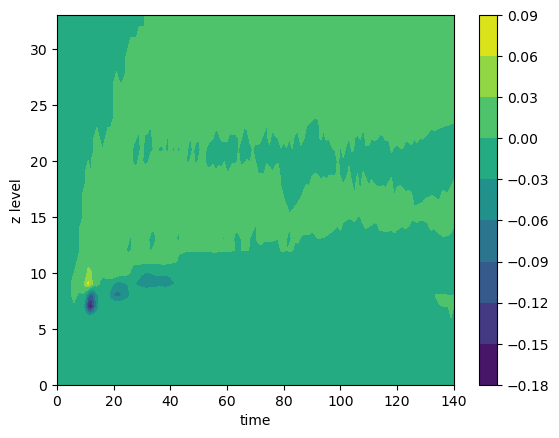

In [189]:
plt.contourf(entrain.T)
plt.colorbar()
plt.xlabel('time');plt.ylabel('z level')

Text(0, 0.5, 'z (km)')

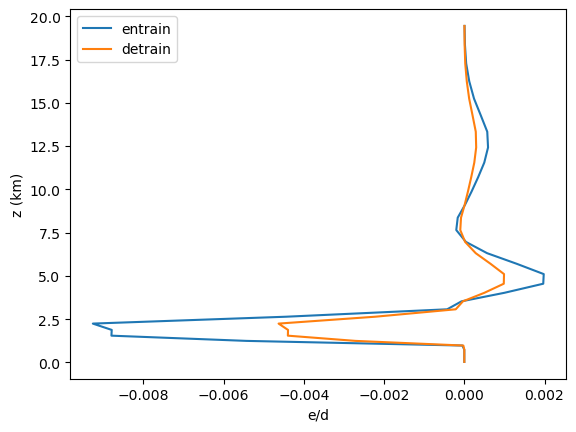

In [206]:
entrain_mean=np.mean(entrain,axis=0)
plt.plot(entrain_mean,data['zh'].values,label='entrain')

detrain_mean=np.mean(detrain,axis=0)
plt.plot(detrain_mean,data['zh'].values,label='detrain')

plt.legend()
plt.xlabel('e/d');plt.ylabel('z (km)')